## NMD Models: NMD Floor (Floorlet Valuation)

This notebook shows how to develop the NMD Floor to meansure the **Floorlet** Valuation.

### Input from other components
| Input | From | Use for |
|---|---|---|
| `runoff profile` | Notebook 05 Runoff proflie  | Balance per period |
| `sigma_r` (The Sigma, now `sigma_m` for monthly and `sigma_n` for annualised) `sigma_m * np.sqrt(12)` | Notebook 06 Carlibration | Normal volatility |

### Core idea
The deposit rates **cannot** practically fall below 0%, as customers would withdraw their funds instead. Therefore, deposit rates inherently have a **built-in floor**.
```
d_effective = max(d_model, floor_strike)
```
The value of this floor represents an **implicit benefit** that customers provide to the bank. Customers absorb the downside when rates are low, rather than demanding market rates.

### Floor = ΣFloorlet
The horizon is divided into 60 periods, with one floorlet assigned to each period.
```
Floorlet payoff_t = D_t × max(K − r_t, 0).
Floor value = ΣPV(Floorlet_t)  for t = 1 to 60.
```

### Pricing Model - Bachelier Model
The Bachelier model is used instead of Black’s log-normal model, because Black yields a value of zero when the strike is significantly below the forward rate (i.e., deep out-of-the-money), which occurs frequently in high interest rate environments.
```
Floorlet = D × P(0,T) × [(K − F)·N(−d) + σ_n·√T·n(d)]
d = (F − K) / (σ_n·√T)
```
where `σ_n` = normal (absolute) volatility of rate per year.

In [1]:
# Set autoreload
%load_ext autoreload
%autoreload 2

In [2]:
# Import libraries
import warnings
import numpy as np
import pandas as pd
import pickle
import sys; sys.path.insert(0, "..")

from src.nmd_floor import price_nmd_floor, floor_sensitivity
from src.plot_function import plot_floor_results

pd.options.display.float_format = "{:.3f}".format
warnings.simplefilter(action = "ignore", category = pd.errors.PerformanceWarning)

In [3]:
# Load Data
df = pd.read_parquet(
    '../data/raw/nmd_data.parquet',
    engine = "pyarrow"
)

# Extract information
market_rate = df["market_rate"]
deposit_rate = df["deposit_rate"]
balance = df["balance"]

# Show
df[["market_rate", "deposit_rate", "balance"]].describe()

,market_rate,deposit_rate,balance
count,150.000,150.000,150.000
mean,0.049,0.009,5185.951
std,0.007,0.002,335.315
min,0.028,0.004,4523.784
25%,0.044,0.008,4880.310
50%,0.048,0.009,5256.091
75%,0.054,0.010,5414.796
max,0.064,0.012,6083.954


In [4]:
# Import related models
# Import runoff model
with open("../model/runoff_model.pkl", "rb") as file:
    bal_profile = pickle.load(file)

# Import dynamics model
with open("../model/dynamics_model.pkl", "rb") as file:
    dynamics_model = pickle.load(file)

In [5]:
# Get upstream parameters
vol_info = dynamics_model["rate"] #Sigma_r
vol_info["sigma_n"] = float(vol_info["sigma_r"] * np.sqrt(12)) #Annualised

# Show
print("=" * 60)
print(f"{"sigma_m (Monthly)":<{25}}: {vol_info['sigma_r']:.4f}")
print(f"{"sigma_n (Annualised)":<{25}}: {vol_info['sigma_n']:.4f}")
print(f"{"r0 (Current rate)":<{25}}: {vol_info['r0']:.2%}")
print(f"{"mu (AR1)":<{25}}: {vol_info['mu']:.4f}")
print("=" * 60)

sigma_m (Monthly)        : 0.0039
sigma_n (Annualised)     : 0.0134
r0 (Current rate)        : 4.55%
mu (AR1)                 : 0.0752


In [6]:
## Build forward curve
"""
Build a flat forward rate curve from the current market rate.

Uses the most recent market rate as a flat forward rate assumption
across all future periods. This is a simplification consistent with
using the current yield curve for IRRBB EVE Calculations.
"""
N_MONTHS = 60 #Regulatory capped

# Flat curve
forward_rates = np.full(
    N_MONTHS,
    float(market_rate.iloc[-1])
)

# Result
print("=" * 60)
print(f"Latest forward rate: {forward_rates[0]:.2%}")
print("=" * 60)

Latest forward rate: 4.55%


In [7]:
# Price NMD Floor
STRIKE_ZERO = 0.0 #Zero-floor (K=0%)
STRIKE_ATM = float(deposit_rate.iloc[-1]) #At-the-money (K = current deposit rate)

floor_zero = price_nmd_floor(
    balance_profile = bal_profile["balance_profile"],
    forward_rates = forward_rates,
    sigma_n = vol_info["sigma_n"],
    r0 = vol_info["r0"],
    strike = STRIKE_ZERO,
    n_months = N_MONTHS
)

floor_atm = price_nmd_floor(
    balance_profile = bal_profile["balance_profile"],
    forward_rates = forward_rates,
    sigma_n = vol_info["sigma_n"],
    r0 = vol_info["r0"],
    strike = STRIKE_ATM,
    n_months = N_MONTHS
)

# Result
print("=" * 60)
print("Zero-floor (K: 0%)")
print(f"{"Floor value":<{15}}: {floor_zero['floor_value']:,.3f} MB")
print(f"{"% of core":<{15}}: {floor_zero['pct_of_core']:.2%}")
print("=" * 60)
print(f"At-the-money (K: {STRIKE_ATM:.2%} (d0))")
print(f"{"Floor value":<{15}}: {floor_atm['floor_value']:,.3f} MB")
print(f"{"% of core":<{15}}: {floor_atm['pct_of_core']:.2%}")
print("=" * 60)

Zero-floor (K: 0%)
Floor value    : 21.280 MB
% of core      : 0.55%
At-the-money (K: 0.73% (d0))
Floor value    : 43.429 MB
% of core      : 1.13%


In [8]:
# Greeks of the NMD floor
for label, strike, floor_res in [
    ("Zero-floor (K: 0%)", STRIKE_ZERO, floor_zero),
    (f"At-the-money (K: {STRIKE_ATM:.2%} (d0))", STRIKE_ATM,  floor_atm)
]:
    greeks = floor_sensitivity(
        balance_profile = bal_profile["balance_profile"],
        forward_rates = forward_rates,
        sigma_n = vol_info["sigma_n"],
        r0 = vol_info["r0"],
        strike = strike
    )

    # Result
    print("=" * 60)
    print(f"{label}")
    print(f"{"Floor value":<{15}}: {floor_res['floor_value']:,.3f} MB")
    print(f"{"Delta":<{15}}: {greeks['delta_per_bps']:,.3f} MB per 1bps rate shift")
    print(f"{"Vega":<{15}}: {greeks['vega_per_bps']:,.3f} MB per 1bps vol shift")
print("=" * 60)

Zero-floor (K: 0%)
Floor value    : 21.280 MB
Delta          : -0.221 MB per 1bps rate shift
Vega           : 0.879 MB per 1bps vol shift
At-the-money (K: 0.73% (d0))
Floor value    : 43.429 MB
Delta          : -0.429 MB per 1bps rate shift
Vega           : 1.497 MB per 1bps vol shift


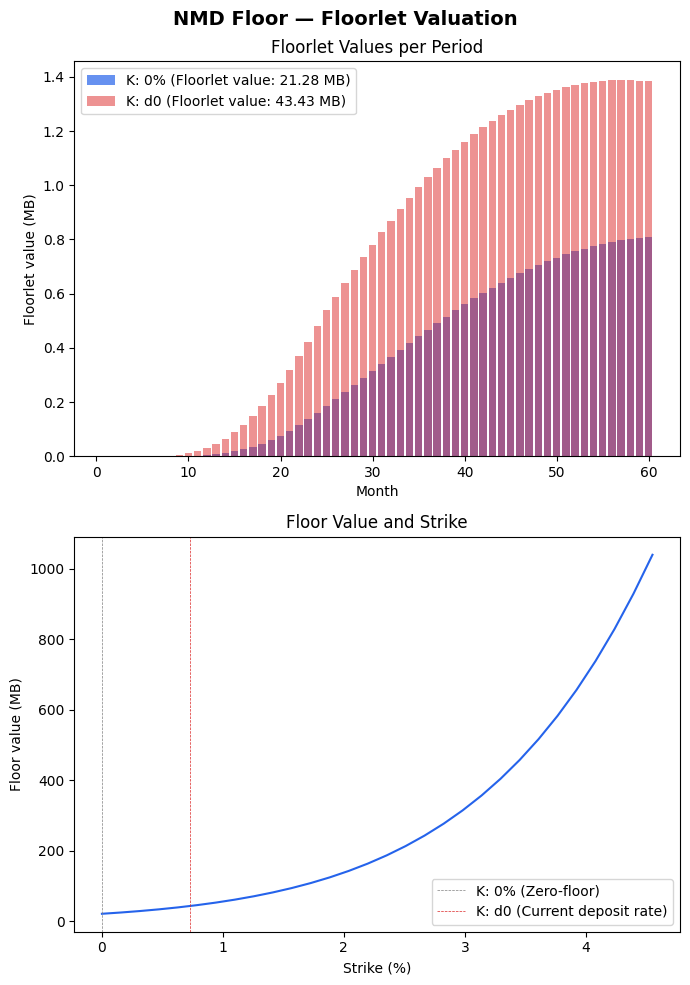

In [10]:
# Plot visualise results
plot_floor_results(
    bal_profile = bal_profile,
    floor_result = floor_zero,
    floor_result_atm = floor_atm,
    forward_rates = forward_rates,
    vol_info = vol_info,
    deposit_rate = deposit_rate
)